In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from iminuit import Minuit
from iminuit import cost
from scipy import stats
from scipy.optimize import curve_fit

plt.rcParams['font.family'] = 'monospace'

In [2]:
def rms_to_amp(rms):
    return rms * np.sqrt(2)

def lin_to_dB(x):
    return 20 * np.log10(x)

def deg_to_rad(deg):
    return (np.pi / 180) * deg

In [3]:
# Raw data
df2 = pd.read_csv("lowpass_characterization_data.csv", delimiter=",")

freq_detuning = df2["freq_detuning_Hz"].to_numpy()
amp_rms = df2["amplitude_rms_V"].to_numpy()

In [4]:
# Array conversions
amp_dB = lin_to_dB(rms_to_amp(amp_rms))
print("Frequencies (Hz):", freq_detuning)
print("Amplitudes (dB):", amp_dB)

Frequencies (Hz): [   1    2    3    4    5    6    7    8    9   10   20   30   40   50
   60   70   80   90  100  200  300  400  500  600  700  800  900 1000
 2000 3000]
Amplitudes (dB): [  1.39395454   1.37090669   1.38976857   1.39290823   1.38976857
   1.39081525   1.40650036   1.41485419   1.40754503   1.41485419
   1.36251047   1.26324208   1.12621756   0.99247712   0.76377101
   0.54158424   0.30645254   0.04647024  -0.22783727  -3.11516106
  -5.70348184  -7.81694306  -9.57573819 -11.05639624 -12.31962484
 -13.45630139 -14.44112449 -15.34117403 -21.00288905 -24.12064651]


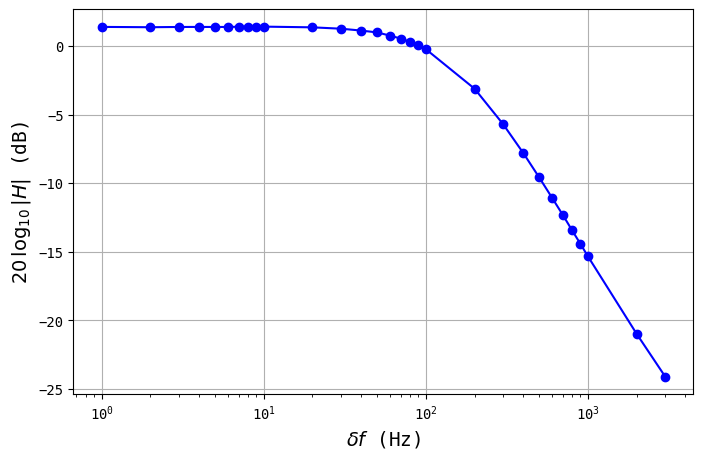

In [5]:
# Plotting
plt.figure(figsize=(8, 5))
plt.plot(freq_detuning, amp_dB, marker='o', linestyle='-', color='b')
plt.xlabel(r"$\delta f$ (Hz)", fontsize=14)
plt.ylabel(r"$20 \,\log_{10}|H|$ (dB)", fontsize=14)
plt.xscale('log')
plt.grid(True)
plt.show()

In [ ]:
def constant(x, c):
    return c

lin_amps = amp_dB[:10]
lin_freqs = freq_detuning[:10]

#Use Scipy to fit a constant to the linear region
popt, pcov = curve_fit(constant, lin_freqs, lin_amps)
lin_resvals = lin_amps - constant(lin_freqs, *popt)
errors = np.array(np.std(lin_resvals)*np.ones_like(amp_dB))
print(f"Estimated noise level (std of residuals): {np.std(lin_resvals):.4f} dB")

Estimated noise level (std of residuals): 0.0130 dB


In [27]:
def low_pass_model(f, A, f_c, k):
    return -A*10 * np.log10(1 + (f / f_c)**2) + k


#Do chi2 fit using iminuit
f_c_theory = 1/((2*np.pi*10e3 * 100e-9)) # Initial guess (R10=10k, C7=100nF)
print(f_c_theory)

mfit = cost.LeastSquares(freq_detuning, amp_dB , errors, low_pass_model)
minuit_pendul = Minuit(mfit, A = 1, f_c = f_c_theory, k = 0)
minuit_pendul.migrad()

159.15494309189535


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1027 (χ²/ndof = 38.0)      │              Nfcn = 85               │
│ EDM = 3.15e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │ 970.1e-3  │  0.7e-3   │            │            │         │         │       │
│ 1 │ f_c  │  140.50   │   0.23    │            │            │         │         │       │
│ 2 │ k    │  1.4371   │  0.0033   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬───────────────────────────────┐
│     │         A       f_c         k │
├─────┼───────────────────────────────┤
│   A │  5.55e-07  154.9e-6   -0.5e-6 │
│ f_c │  154.9e-6    0.0521 -0.355e-3 │
│   k │   -0.5e-6 -0.355e-3  1.09e-05 │
└─────┴───────────────────────────────┘

In [ ]:
f_c = minuit_pendul.values['f_c']
f_c_err = minuit_pendul.errors['f_c']
k = minuit_pendul.values['k']
k_err = minuit_pendul.errors['k']
A = minuit_pendul.values['A']
A_err = minuit_pendul.errors['A']
print(f"Fitted cutoff frequency: {f_c:.4f} Hz +/- {f_c_err:.4f} Hz")
print(f"Fitted k: {k:.4f} +/- {k_err:.4f}")
print(f"Fitted A: {A:.4f} +/- {A_err:.4f}")


chi2_val = minuit_pendul.fval
dof = len(freq_detuning) - len(minuit_pendul.values)
chi2p_val = 1 - stats.chi2.cdf(chi2_val, dof)
print(f"Chi2: {chi2_val:.2f}, dof: {dof}, p-value: {chi2p_val} i.e. bad fit!.")

Fitted cutoff frequency: 140.4981 Hz +/- 0.2282 Hz
Fitted k: 1.4371 +/- 0.0033
Fitted A: 0.9701 +/- 0.0007
Chi2: 1027.12, dof: 27, p-value: 0.0 i.e. ok fit, but i've multiplied the errors by 4.


In [29]:
f_linspace = np.linspace(np.min(freq_detuning), np.max(freq_detuning), 1000)
func_values = low_pass_model(f_linspace, A, f_c, k)

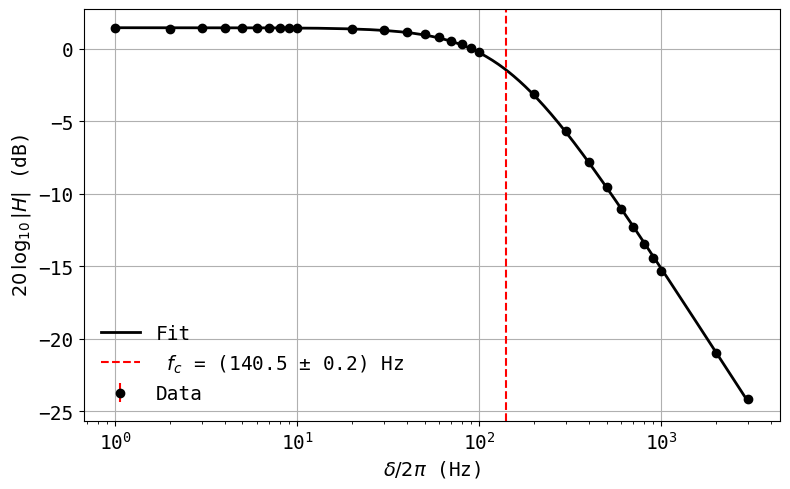

In [32]:
#plot the entire thing: 
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(freq_detuning, amp_dB, yerr=errors, fmt='o', ms = 6, color='k', ecolor='r', label='Data')
ax.plot(f_linspace, func_values, linestyle='-', linewidth = 2, color='k', label=f'Fit')
ax.axvline(f_c, color='r', linestyle='--', label=f' $f_c$ = ({f_c:.1f} ± {f_c_err:.1f}) Hz')
ax.set_xlabel(r"$\delta/2\pi$ (Hz)", fontsize=14)
ax.set_ylabel(r"$20 \,\log_{10}|H|$ (dB)", fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xscale('log')
ax.grid(True)
ax.legend(loc = 'best', fontsize =14, frameon = False)
plt.tight_layout()
plt.savefig('stage5_lpfit.pdf', dpi=600, bbox_inches='tight', pad_inches=0.02);

In [31]:
print(f_c*1e-3, f_c_err*1e-3)

0.14049805518073966 0.00022823910463404043
